In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os


In [30]:
data_path = "../data"
processed_dir = os.path.join(data_path, "processed")
augmented_dir = os.path.join(data_path, "augmented")


In [31]:
splits = [
	("train", processed_dir), 
	("dev", processed_dir), 
	("test", processed_dir)
]

dfs = []
for split, dir in splits:
	path = os.path.join(dir, f"stsb-es-{split}.csv",)
	df = pd.read_csv(path)
	dfs.append(df)

df = pd.concat(dfs, ignore_index=True)


In [32]:
df.columns


Index(['sentence1', 'sentence2', 'score', 'split', 'score_norm'], dtype='str')

In [33]:
df["split"].unique()


<StringArray>
['train', 'dev', 'test']
Length: 3, dtype: str

In [34]:
df.describe()


,score,score_norm
count,8628.000000,8628.000000
mean,2.627518,0.525504
std,1.485762,0.297152
min,0.000000,0.000000
25%,1.400000,0.280000
50%,2.800000,0.560000
75%,3.800000,0.760000
max,5.000000,1.000000


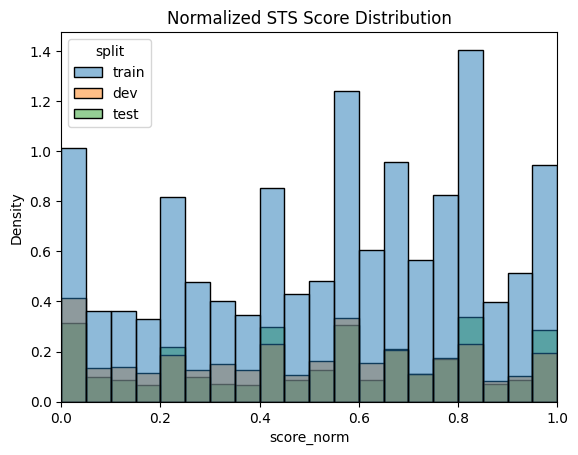

In [35]:
sns.histplot(df, x="score_norm", hue="split", bins=20, stat="density")
plt.title("Normalized STS Score Distribution")
plt.xlim(0,1)
plt.show()


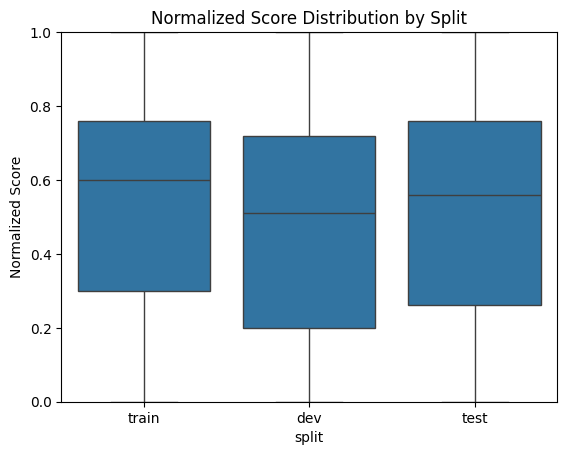

In [36]:
sns.boxplot(data=df, x="split", y="score_norm")

plt.title("Normalized Score Distribution by Split")
plt.ylabel("Normalized Score")
plt.ylim(0, 1)
plt.show()

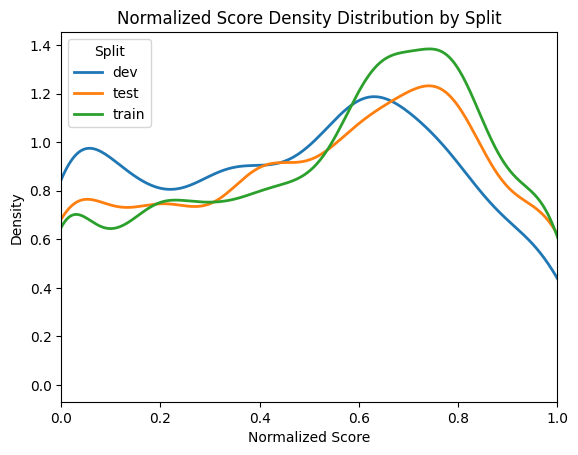

In [37]:
for split, data in df.groupby("split"):
	data["score_norm"].plot(kind="kde", label=split, linewidth=2)

plt.xlabel("Normalized Score")
plt.ylabel("Density")
plt.title("Normalized Score Density Distribution by Split")
plt.xlim(0, 1)
plt.legend(title="Split")
plt.show()

In [38]:
df["len1"] = df["sentence1"].str.split().str.len()
df["len2"] = df["sentence2"].str.split().str.len()

In [39]:
df[["len1", "len2"]].describe()

,len1,len2
count,8628.000000,8628.000000
mean,12.097821,12.040218
std,6.588797,6.454476
min,2.000000,2.000000
25%,8.000000,7.000000
50%,10.000000,10.000000
75%,15.000000,14.000000
max,77.000000,58.000000


In [40]:
PERCENTILE = 95

lengths = pd.concat([df["len1"], df["len2"]])
max_len = int(np.percentile(lengths, PERCENTILE))

print(max_len)

26


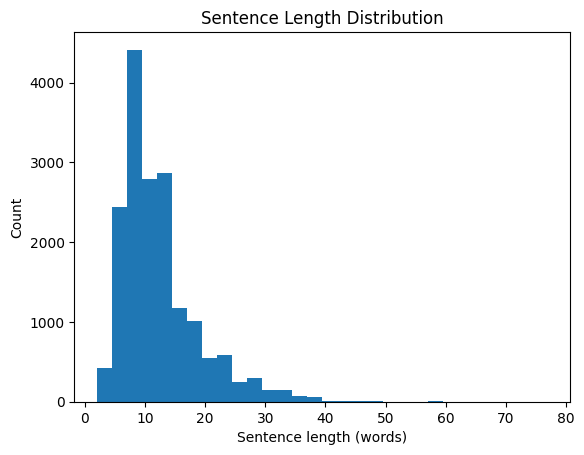

In [41]:
lengths = pd.concat([df["len1"], df["len2"]])

plt.hist(lengths, bins=30)
plt.xlabel("Sentence length (words)")
plt.ylabel("Count")
plt.title("Sentence Length Distribution")
plt.show()

In [42]:
truncated = (df["len1"] > max_len).sum() + (df["len2"] > max_len).sum()
total = len(df) * 2

all_lengths = np.concatenate([df["len1"].values, df["len2"].values])

# գտ 95th percentile (keeps truncation ≈ 5%)
max_len = int(np.percentile(all_lengths, 95))

print("Suggested max_len:", max_len)

# Now compute truncation rate
truncated = (df["len1"] > max_len).sum() + (df["len2"] > max_len).sum()
total = len(df) * 2

print("Truncation rate:", truncated / total)


Suggested max_len: 26
Truncation rate: 0.04421650440426518
